In [14]:
import numpy as np
import pandas as pd
import pywt
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import accuracy_score, classification_report
import warnings
import requests
import io

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Используемое вычислительное устройство: {device}")
warnings.filterwarnings('ignore')

Используемое вычислительное устройство: cuda


In [15]:
print("Загрузка данных с GitHub...")

# URL-адреса raw файлов
url_train_eeg = "https://raw.githubusercontent.com/D2718281828nis/BioMedAI/main/test_datasets/MI-EEG-B9T.csv"
url_test_eeg = "https://raw.githubusercontent.com/D2718281828nis/BioMedAI/main/test_datasets/MI-EEG-B9E.csv"
url_train_target = "https://raw.githubusercontent.com/TAUforPython/BioMedAI/main/test_datasets/2class_MI_EEG_train_9.csv"
url_test_target = "https://raw.githubusercontent.com/TAUforPython/BioMedAI/main/test_datasets/2class_MI_EEG_test_9.csv"

# Загружаем все файлы
response_train_eeg = requests.get(url_train_eeg)
response_test_eeg = requests.get(url_test_eeg)
response_train_target = requests.get(url_train_target)
response_test_target = requests.get(url_test_target)

# Проверяем успешность загрузки
for name, response in [("Train EEG", response_train_eeg),
                        ("Test EEG", response_test_eeg),
                        ("Train Target", response_train_target),
                        ("Test Target", response_test_target)]:
    if response.status_code == 200:
        print(f"✓ {name} загружен успешно")
    else:
        print(f"✗ Ошибка загрузки {name}: статус {response.status_code}")

# Читаем CSV из загруженных данных
X_train_df = pd.read_csv(io.StringIO(response_train_eeg.text), header=None)
y_train_df = pd.read_csv(io.StringIO(response_train_target.text), header=None)

X_test_df = pd.read_csv(io.StringIO(response_test_eeg.text), header=None)
y_test_df = pd.read_csv(io.StringIO(response_test_target.text), header=None)

# Преобразование в массивы numpy
X_train = X_train_df.values
y_train = y_train_df.values.squeeze()
X_test = X_test_df.values
y_test = y_test_df.values.squeeze()

# Обработка меток, чтобы они начинались с 0 (если это 1 и 2, преобразовать в 0 и 1)
if y_train.min() > 0:
    y_train = y_train - y_train.min()
    y_test = y_test - y_test.min()

print(f"Форма сигналов обучающей выборки: {X_train.shape}, форма меток: {y_train.shape}")
print(f"Форма сигналов тестовой выборки: {X_test.shape}, форма меток: {y_test.shape}")

Загрузка данных с GitHub...
✓ Train EEG загружен успешно
✓ Test EEG загружен успешно
✓ Train Target загружен успешно
✓ Test Target загружен успешно
Форма сигналов обучающей выборки: (400, 3000), форма меток: (400,)
Форма сигналов тестовой выборки: (320, 3000), форма меток: (320,)


Выполняется вейвлет-преобразование, это может занять некоторое время...
Форма изображений обучающей выборки после преобразования: (400, 1, 32, 3000)


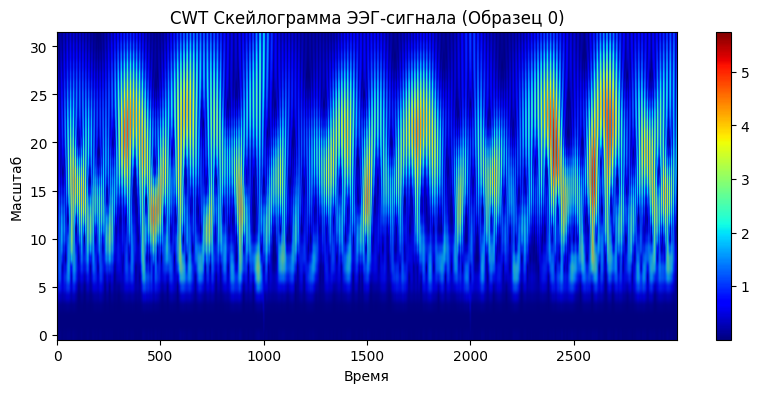

In [16]:
# Вейвлет-преобразование
def apply_cwt(data, scales, wavelet_name='morl'):
    """
    Выполняет непрерывное вейвлет-преобразование одномерного ЭЭГ-сигнала,
    создаёт двумерную частотно-временную диаграмму
    data: shape (n_samples, n_timepoints)
    Возвращает: тензор изображения shape (n_samples, 1, n_scales, n_timepoints)
    """
    n_samples = data.shape[0]
    n_timepoints = data.shape[1]
    n_scales = len(scales)

    # Инициализация выходного массива с добавлением канального измерения (Channel=1)
    # для соответствия входу сверточной нейронной сети
    cwt_images = np.zeros((n_samples, 1, n_scales, n_timepoints))

    for i in range(n_samples):
        signal = data[i, :]
        # Выполнение непрерывного вейвлет-преобразования
        coefs, freqs = pywt.cwt(signal, scales, wavelet_name)
        # Использование абсолютного значения (амплитуды) как значения пикселя изображения
        cwt_images[i, 0, :, :] = np.abs(coefs)

    return cwt_images

# Определение масштабов для вейвлет-преобразования (определяет диапазон частот)
# Меньший масштаб соответствует высокой частоте; больший масштаб – низкой частоте.
# Здесь выбран диапазон от 1 до 32
scales = np.arange(1, 33)
print("Выполняется вейвлет-преобразование, это может занять некоторое время...")

X_train_cwt = apply_cwt(X_train, scales)
X_test_cwt = apply_cwt(X_test, scales)

print(f"Форма изображений обучающей выборки после преобразования: {X_train_cwt.shape}")

# Визуализация частотно-временной диаграммы одного образца
plt.figure(figsize=(10, 4))
plt.imshow(X_train_cwt[0, 0, :, :], aspect='auto', cmap='jet', origin='lower')
plt.title("CWT Скейлограмма ЭЭГ-сигнала (Образец 0)")
plt.ylabel("Масштаб")
plt.xlabel("Время")
plt.colorbar()
plt.show()

In [17]:
# Dataset и DataLoader
class EEGImageDataset(Dataset):
    def __init__(self, features, labels):
        self.features = torch.tensor(features, dtype=torch.float32)
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.features[idx], self.labels[idx]

train_dataset = EEGImageDataset(X_train_cwt, y_train)
test_dataset = EEGImageDataset(X_test_cwt, y_test)

batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [18]:
class EEG_CNN(nn.Module):
    def __init__(self, num_classes=2):
        super(EEG_CNN, self).__init__()

        self.conv_block1 = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=16, kernel_size=(3, 3), padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=(2, 2))
        )

        self.conv_block2 = nn.Sequential(
            nn.Conv2d(in_channels=16, out_channels=32, kernel_size=(3, 3), padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=(2, 2))
        )

        self.adaptive_pool = nn.AdaptiveAvgPool2d((8, 8))

        self.classifier = nn.Sequential(
            nn.Linear(32 * 8 * 8, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.conv_block1(x)
        x = self.conv_block2(x)
        x = self.adaptive_pool(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x

model = EEG_CNN(num_classes=2).to(device)
print(model)

EEG_CNN(
  (conv_block1): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=(2, 2), stride=(2, 2), padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block2): Sequential(
    (0): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=(2, 2), stride=(2, 2), padding=0, dilation=1, ceil_mode=False)
  )
  (adaptive_pool): AdaptiveAvgPool2d(output_size=(8, 8))
  (classifier): Sequential(
    (0): Linear(in_features=2048, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.5, inplace=False)
    (3): Linear(in_features=128, out_features=2, bias=True)
  )
)


Начало обучения сети...
Эпоха [1/100]
  Train - Потери: 0.8454, Точность: 0.5225
  Test  - Потери: 0.6842, Точность: 0.5000
Эпоха [5/100]
  Train - Потери: 0.6719, Точность: 0.5875
  Test  - Потери: 0.6652, Точность: 0.5000
Эпоха [10/100]
  Train - Потери: 0.6286, Точность: 0.6600
  Test  - Потери: 0.5822, Точность: 0.7812
Эпоха [15/100]
  Train - Потери: 0.5751, Точность: 0.7250
  Test  - Потери: 0.5371, Точность: 0.7063
Эпоха [20/100]
  Train - Потери: 0.5373, Точность: 0.7150
  Test  - Потери: 0.4883, Точность: 0.7562
Эпоха [25/100]
  Train - Потери: 0.5172, Точность: 0.7400
  Test  - Потери: 0.4399, Точность: 0.7844
Эпоха [30/100]
  Train - Потери: 0.5276, Точность: 0.7150
  Test  - Потери: 0.4667, Точность: 0.7875
Эпоха [35/100]
  Train - Потери: 0.4822, Точность: 0.7600
  Test  - Потери: 0.4447, Точность: 0.7937
Эпоха [40/100]
  Train - Потери: 0.4770, Точность: 0.7650
  Test  - Потери: 0.4716, Точность: 0.7781
Эпоха [45/100]
  Train - Потери: 0.4225, Точность: 0.8000
  Test  - П

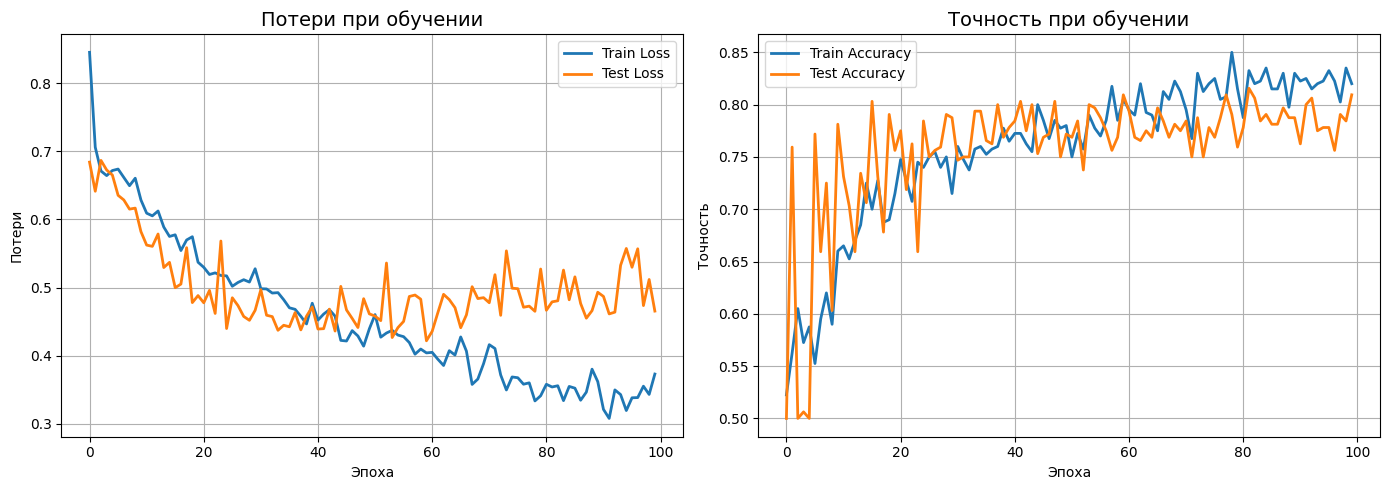

In [19]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

num_epochs = 100
train_losses = []
test_losses = []
train_accuracies = []
test_accuracies = []

print("Начало обучения сети...")
for epoch in range(num_epochs):
    # Обучение
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_train_loss = running_loss / total
    epoch_train_acc = correct / total
    train_losses.append(epoch_train_loss)
    train_accuracies.append(epoch_train_acc)

    # Оценка на тестовой выборке
    model.eval()
    test_loss = 0.0
    test_correct = 0
    test_total = 0

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            test_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs.data, 1)
            test_total += labels.size(0)
            test_correct += (predicted == labels).sum().item()

    epoch_test_loss = test_loss / test_total
    epoch_test_acc = test_correct / test_total
    test_losses.append(epoch_test_loss)
    test_accuracies.append(epoch_test_acc)

    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Эпоха [{epoch+1}/{num_epochs}]")
        print(f"  Train - Потери: {epoch_train_loss:.4f}, Точность: {epoch_train_acc:.4f}")
        print(f"  Test  - Потери: {epoch_test_loss:.4f}, Точность: {epoch_test_acc:.4f}")

# Построение графиков потерь и точности для train и test
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# График потерь
axes[0].plot(train_losses, label='Train Loss', linewidth=2)
axes[0].plot(test_losses, label='Test Loss', linewidth=2)
axes[0].set_title('Потери при обучении', fontsize=14)
axes[0].set_xlabel('Эпоха')
axes[0].set_ylabel('Потери')
axes[0].legend()
axes[0].grid(True)

# График точности
axes[1].plot(train_accuracies, label='Train Accuracy', linewidth=2)
axes[1].plot(test_accuracies, label='Test Accuracy', linewidth=2)
axes[1].set_title('Точность при обучении', fontsize=14)
axes[1].set_xlabel('Эпоха')
axes[1].set_ylabel('Точность')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

Итоговая точность на тестовой выборке (Accuracy): 80.94%

Детальный отчёт классификации:
              precision    recall  f1-score   support

 Левый кулак       0.80      0.82      0.81       160
Правый кулак       0.82      0.80      0.81       160

    accuracy                           0.81       320
   macro avg       0.81      0.81      0.81       320
weighted avg       0.81      0.81      0.81       320



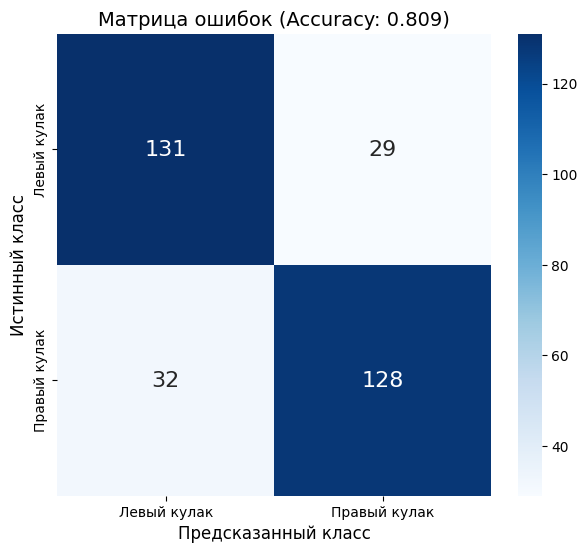

In [20]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs.data, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

acc = accuracy_score(all_labels, all_preds)
print(f"Итоговая точность на тестовой выборке (Accuracy): {acc * 100:.2f}%\n")
print("Детальный отчёт классификации:")
print(classification_report(all_labels, all_preds, target_names=['Левый кулак', 'Правый кулак']))

# Матрица ошибок
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Левый кулак', 'Правый кулак'],
            yticklabels=['Левый кулак', 'Правый кулак'],
            annot_kws={'size': 16})
plt.title(f'Матрица ошибок (Accuracy: {acc:.3f})', fontsize=14)
plt.ylabel('Истинный класс', fontsize=12)
plt.xlabel('Предсказанный класс', fontsize=12)
plt.show()